# MNIST: Data Preparation

**Prepared by Fonyuy Gita — SEED AI Bootcamp, Deep Learning Module (CNN track)**

This notebook prepares the MNIST handwritten digits dataset for a CNN.
The overall approach mirrors `01_cifar10_data_preparation.ipynb`, load,
inspect, normalize, split, save, but MNIST is a simpler dataset in a few
important ways, which makes it an easier place to build CNN intuition
before tackling the harder CIFAR-10 photographs.

**Same data-loading philosophy as CIFAR-10:** we load MNIST from local
files rather than a built-in downloader. Keras ships a convenience
loader, `keras.datasets.mnist.load_data()`, but it fetches the file from
Google Cloud Storage at run time, which fails outright on restricted or
firewalled networks (a `403 Forbidden` error is common in locked-down
classroom or lab environments). Loading from local files, exactly like
the CIFAR-10 `.tar.gz` approach, means this notebook runs with zero
internet access once the files are on disk.

**What this notebook covers:**
1. What MNIST is, and how it compares to CIFAR-10
2. How the raw IDX file format works
3. Load and decode the raw files
4. Inspect and visualize
5. Normalize and reshape
6. Split into train / validation / test
7. Save the prepared arrays for the CNN training notebook


## Step 0: Get the dataset files

Download these four files and place them in the same folder as this
notebook:

```
https://raw.githubusercontent.com/fgnt/mnist/master/train-images-idx3-ubyte.gz
https://raw.githubusercontent.com/fgnt/mnist/master/train-labels-idx1-ubyte.gz
https://raw.githubusercontent.com/fgnt/mnist/master/t10k-images-idx3-ubyte.gz
https://raw.githubusercontent.com/fgnt/mnist/master/t10k-labels-idx1-ubyte.gz
```

You can download them with `wget` from a terminal:

```bash
wget https://raw.githubusercontent.com/fgnt/mnist/master/train-images-idx3-ubyte.gz
wget https://raw.githubusercontent.com/fgnt/mnist/master/train-labels-idx1-ubyte.gz
wget https://raw.githubusercontent.com/fgnt/mnist/master/t10k-images-idx3-ubyte.gz
wget https://raw.githubusercontent.com/fgnt/mnist/master/t10k-labels-idx1-ubyte.gz
```

This is a mirror of the original MNIST release (the original host,
Yann LeCun's NYU page, has had long-term reliability problems, this
GitHub mirror is the commonly used stable alternative).

### What is MNIST?

MNIST is **70,000 grayscale images of handwritten digits**, 0 through 9,
each **28x28 pixels**, split into 60,000 training images and 10,000 test
images. It's one of the oldest and most famous datasets in machine
learning, still widely used as a first CNN project because it's small,
clean, and fast to train on.

### MNIST vs CIFAR-10, side by side

| | MNIST | CIFAR-10 |
|---|---|---|
| Image size | 28x28 | 32x32 |
| Color channels | 1 (grayscale) | 3 (RGB color) |
| Classes | 10 (digits 0-9) | 10 (objects/animals) |
| What's being recognized | A single handwritten shape on a plain background | A real-world photo with texture, lighting, background clutter |
| Typical difficulty | Easier, a small CNN gets 99%+ accuracy easily | Harder, requires a deeper network and augmentation to do well |

### How the raw IDX file format works

Unlike CIFAR-10's pickled Python dictionaries, MNIST's raw files use a
much older, simpler binary format called **IDX**. Each file starts with
a small fixed header of big-endian 32-bit integers, then the raw pixel
or label bytes follow immediately after:

```
Image file header (16 bytes):
  bytes 0-3:   magic number (2051 for images)
  bytes 4-7:   number of images
  bytes 8-11:  number of rows (28)
  bytes 12-15: number of columns (28)
  ... then every image's pixels back to back, 1 byte per pixel (0-255)

Label file header (8 bytes):
  bytes 0-3: magic number (2049 for labels)
  bytes 4-7: number of labels
  ... then every label back to back, 1 byte per label (0-9)
```

The files are also gzip-compressed (hence the `.gz` extension), so we
decompress on the fly while reading.


```mermaid
flowchart TD
    A[train-images-idx3-ubyte.gz] -->|gzip decompress| B[raw bytes]
    B -->|read 16-byte header| C["magic, count, rows, cols"]
    B -->|read remaining bytes| D["flat uint8 array"]
    C --> E["reshape to (count, 28, 28)"]
    D --> E
    F[train-labels-idx1-ubyte.gz] -->|gzip decompress| G[raw bytes]
    G -->|read 8-byte header, then labels| H["array of 60,000 integers 0-9"]
    E --> I["Normalize: divide by 255 -> range 0 to 1"]
    I --> J["Add channel dimension: 28x28 -> 28x28x1"]
    H --> K["Split off validation set"]
    J --> K
```

**Why add a channel dimension?** Keras' `Conv2D` layers expect images in
the shape `(height, width, channels)`, always, even for grayscale. MNIST
images naturally come as `(28, 28)`, with no channel dimension at all, so
we have to explicitly add one, becoming `(28, 28, 1)`. CIFAR-10 didn't
need this step since color images already have 3 channels built in.


## Step 1: Import libraries

In [1]:
import gzip
import struct

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


## Step 2: Write functions to decode the IDX format

We read the header manually using Python's `struct` module, then read
the rest of the file as a flat block of bytes and reshape it.

In [2]:
def load_idx_images(path):
    """Decode an IDX3 image file (gzip-compressed) into a NumPy array."""
    with gzip.open(path, 'rb') as f:
        # '>IIII' = 4 big-endian unsigned 32-bit integers
        magic, num_images, num_rows, num_cols = struct.unpack('>IIII', f.read(16))
        assert magic == 2051, f"Unexpected magic number {magic}, is this really an image file?"

        buffer = f.read(num_rows * num_cols * num_images)
        images = np.frombuffer(buffer, dtype=np.uint8)
        images = images.reshape(num_images, num_rows, num_cols)
    return images


def load_idx_labels(path):
    """Decode an IDX1 label file (gzip-compressed) into a NumPy array."""
    with gzip.open(path, 'rb') as f:
        # '>II' = 2 big-endian unsigned 32-bit integers
        magic, num_labels = struct.unpack('>II', f.read(8))
        assert magic == 2049, f"Unexpected magic number {magic}, is this really a label file?"

        buffer = f.read(num_labels)
        labels = np.frombuffer(buffer, dtype=np.uint8)
    return labels


## Step 3: Load the dataset

In [3]:
X_train_full = load_idx_images('train-images-idx3-ubyte.gz')
y_train_full = load_idx_labels('train-labels-idx1-ubyte.gz')
X_test = load_idx_images('t10k-images-idx3-ubyte.gz')
y_test = load_idx_labels('t10k-labels-idx1-ubyte.gz')

print(f"Train: {X_train_full.shape}")
print(f"Test:  {X_test.shape}")
print(f"Pixel range: {X_train_full.min()} to {X_train_full.max()}")
print(f"Label range: {y_train_full.min()} to {y_train_full.max()}")


Train: (60000, 28, 28)
Test:  (10000, 28, 28)
Pixel range: 0 to 255
Label range: 0 to 9


## Step 4: Inspect and visualize

In [5]:
# Turple unpacking and parallel iterations,
# unique, count=np.unique()

unique, counts = np.unique(y_train_full, return_counts=True)
print("Class balance in training set:")
for digit, count in zip(unique, counts):
    print(f"  Digit {digit}: {count}")


Class balance in training set:
  Digit 0: 5923
  Digit 1: 6742
  Digit 2: 5958
  Digit 3: 6131
  Digit 4: 5842
  Digit 5: 5421
  Digit 6: 5918
  Digit 7: 6265
  Digit 8: 5851
  Digit 9: 5949


In [9]:
u, c=np.unique([1,2,3,41,3,4,5,12,3,1,3,4,5,6,6, 3,3,2,6], return_counts=True)
for digits, count in zip(u, c):
    print(f"{digits}: {count}")
# unique

1: 2
2: 2
3: 6
4: 2
5: 2
6: 3
12: 1
41: 1


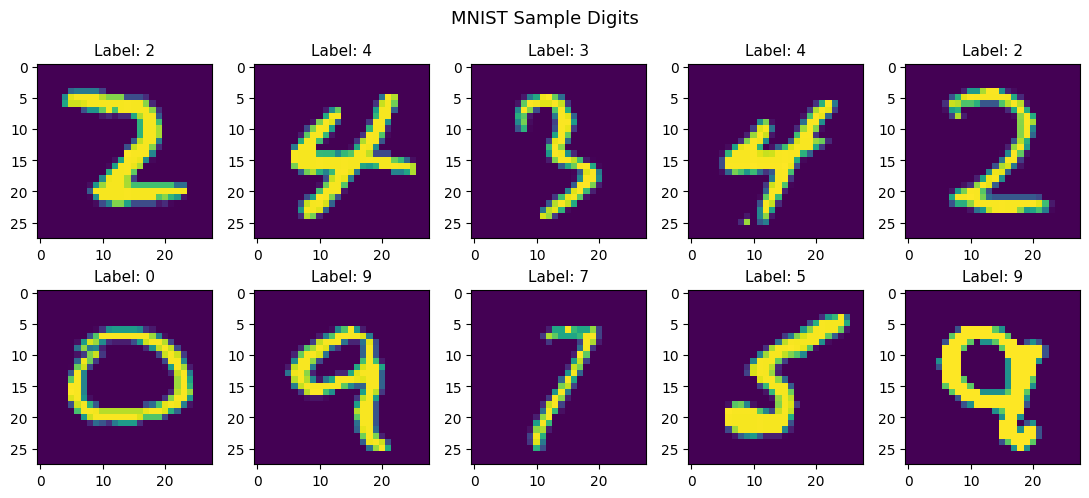

In [25]:
# This code selects 10 random images from your dataset and plots them in
# a 2x5 grid using Matplotlib. It labels each image with its correct
# digit, cleans up the formatting, and saves the result as a PNG file

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(X_train_full), size=10, replace=False)

for ax, idx in zip(axes.flat, sample_indices):
    ax.imshow(X_train_full[idx],)
    ax.set_title(f"Label: {y_train_full[idx]}", fontsize=11)
    # ax.axis('off')

plt.suptitle('MNIST Sample Digits', fontsize=13)
plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()


fig, axes=plt.subplots(2, 5, figsize=(11, 5))
print(f"{fig}: {axes}")
rng=np.random.default_rng(42)
sample_indices=rng.choice(len(X_train_full), size=10, replace=False)
sample_indices

# The plotting loop

for ax, idx in zip(axes.flat,  sample_indices):
    print(f"axes: {ax}")
    ax.imshow(X_train_full[idx], cmap="gray")
    

In [21]:
rng=np.random.default_rng(42)
sample_indices=rng.choice(len(X_train_full), size=10, replace=False)
sample_indices

for ax, idx in zip(axes.flat, sample_indices):
        ax.imshow(X_train_full[idx], cmap='gray')



axes: Axes(0.125,0.53;0.133621x0.35)
axes: Axes(0.285345,0.53;0.133621x0.35)
axes: Axes(0.44569,0.53;0.133621x0.35)
axes: Axes(0.606034,0.53;0.133621x0.35)
axes: Axes(0.766379,0.53;0.133621x0.35)
axes: Axes(0.125,0.11;0.133621x0.35)
axes: Axes(0.285345,0.11;0.133621x0.35)
axes: Axes(0.44569,0.11;0.133621x0.35)
axes: Axes(0.606034,0.11;0.133621x0.35)
axes: Axes(0.766379,0.11;0.133621x0.35)


If these look like real, legible handwritten digits with labels that
match what's on screen, the IDX decoding worked correctly, that's exactly
the kind of visual sanity check you should always do after writing a
custom file parser, a shape or byte-order mistake would show up here as
garbled or shifted images, not as a Python error.

MNIST is close to perfectly balanced across all 10 digits, another
reason it's a forgiving first dataset, no class imbalance to complicate
evaluation.

## Step 5: Normalize and reshape

Same normalization idea as CIFAR-10, scale pixel values from `[0, 255]`
to `[0, 1]`. Then add the explicit channel dimension `Conv2D` expects.

In [26]:
print(f"Before: shape={X_train_full.shape}, dtype={X_train_full.dtype}, range=[{X_train_full.min()}, {X_train_full.max()}]")

X_train_full = X_train_full.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Add the channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
X_train_full = X_train_full[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"After:  shape={X_train_full.shape}, dtype={X_train_full.dtype}, range=[{X_train_full.min():.3f}, {X_train_full.max():.3f}]")


Before: shape=(60000, 28, 28), dtype=uint8, range=[0, 255]
After:  shape=(60000, 28, 28, 1), dtype=float32, range=[0.000, 1.000]


## Step 6: Split off a validation set

In [7]:
VAL_SIZE = 6000

X_val = X_train_full[-VAL_SIZE:]
y_val = y_train_full[-VAL_SIZE:]
X_train = X_train_full[:-VAL_SIZE]
y_train = y_train_full[:-VAL_SIZE]

print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")


Train: 54000
Val:   6000
Test:  10000


## Step 7: Save the prepared arrays

Same reasoning as CIFAR-10: images are saved as `.npy` binary arrays,
not CSV, since a spreadsheet format is a poor fit for pixel grids.

In [8]:
np.save('mnist_X_train.npy', X_train)
np.save('mnist_y_train.npy', y_train)
np.save('mnist_X_val.npy', X_val)
np.save('mnist_y_val.npy', y_val)
np.save('mnist_X_test.npy', X_test)
np.save('mnist_y_test.npy', y_test)

print("Saved:")
print("  mnist_X_train.npy, mnist_y_train.npy")
print("  mnist_X_val.npy,   mnist_y_val.npy")
print("  mnist_X_test.npy,  mnist_y_test.npy")


Saved:
  mnist_X_train.npy, mnist_y_train.npy
  mnist_X_val.npy,   mnist_y_val.npy
  mnist_X_test.npy,  mnist_y_test.npy


### Done

We now have clean, normalized, correctly-shaped MNIST arrays saved to
disk, decoded entirely from local files with no reliance on any
auto-downloader. Open **`02_mnist_cnn_training.ipynb`** next to build and
train the CNN.